<a href="https://colab.research.google.com/github/shaanansari668-boop/GIST-Data-Science-Internship-/blob/main/GIST_Internship_Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ABD UR RAHMAN

# GIST Data Science Internship — Task 1
## Data Cleaning & Exploration

**Internship:** Global Institute of Science & Technology (GIST)  
**Domain:** Data Science  
**Task:** Task 1 — Basic: Data Cleaning & Exploration

### Objective
Clean a real-world student-performance dataset, handle missing values, remove duplicates, identify outliers, calculate descriptive statistics, and create visualizations that help understand the data.

### Dataset
Student Performance Factors. The dataset contains student study habits, attendance, parental/school factors, lifestyle variables, and `Exam_Score`. Source: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

### Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, Google Colab

In [1]:
!pip -q install kagglehub

import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
import kagglehub

dataset_path = kagglehub.dataset_download('lainguyn123/student-performance-factors')
print('Dataset downloaded to:', dataset_path)

csv_files = glob.glob(os.path.join(dataset_path, '**', '*.csv'), recursive=True)
if not csv_files:
    raise FileNotFoundError('CSV file was not found.')

csv_path = csv_files[0]
print('Using:', csv_path)

Using Colab cache for faster access to the 'student-performance-factors' dataset.
Dataset downloaded to: /kaggle/input/student-performance-factors
Using: /kaggle/input/student-performance-factors/StudentPerformanceFactors.csv


In [3]:
df_raw = pd.read_csv(csv_path)
df = df_raw.copy()

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]}')
display(df.head())

Rows: 6,607
Columns: 20


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
print('--- Data types ---')
display(df.dtypes.to_frame('Data Type'))

print('--- Dataset information ---')
df.info()

print('--- Descriptive statistics ---')
display(df.describe(include='all').T)

--- Data types ---


,Data Type
Hours_Studied,int64
Attendance,int64
Parental_Involvement,object
Access_to_Resources,object
Extracurricular_Activities,object
Sleep_Hours,int64
Previous_Scores,int64
Motivation_Level,object
Internet_Access,object
Tutoring_Sessions,int64


--- Dataset information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence      

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,"6,607.00",NaN,NaN,NaN,19.98,5.99,1.00,16.00,20.00,24.00,44.00
Attendance,"6,607.00",NaN,NaN,NaN,79.98,11.55,60.00,70.00,80.00,90.00,100.00
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,"6,607.00",NaN,NaN,NaN,7.03,1.47,4.00,6.00,7.00,8.00,10.00
Previous_Scores,"6,607.00",NaN,NaN,NaN,75.07,14.40,50.00,63.00,75.00,88.00,100.00
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,"6,607.00",NaN,NaN,NaN,1.49,1.23,0.00,1.00,1.00,2.00,8.00


In [6]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)
missing_table = pd.DataFrame({'Missing Values': missing, 'Missing %': missing_pct})
display(missing_table[missing_table['Missing Values'] > 0])

if missing.sum() == 0:
    print('No missing values detected.')
else:
    print(f'Total missing cells: {missing.sum():,}')

,Missing Values,Missing %
Parental_Education_Level,90,1.36
Teacher_Quality,78,1.18
Distance_from_Home,67,1.01


Total missing cells: 235


In [7]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

for col in numeric_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isna().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print('Remaining missing cells:', int(df.isna().sum().sum()))
display(df.isna().sum().to_frame('Remaining Missing Values').query('`Remaining Missing Values` > 0'))

Remaining missing cells: 0


,Remaining Missing Values


In [8]:
duplicate_count = int(df.duplicated().sum())
print('Duplicate rows before removal:', duplicate_count)

df = df.drop_duplicates().reset_index(drop=True)

print('Duplicate rows after removal:', int(df.duplicated().sum()))
print('Rows after duplicate removal:', f'{len(df):,}')

Duplicate rows before removal: 0
Duplicate rows after removal: 0
Rows after duplicate removal: 6,607


In [9]:
numeric_summary = df.select_dtypes(include=np.number).describe().T
display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,"6,607.00",19.98,5.99,1.00,16.00,20.00,24.00,44.00
Attendance,"6,607.00",79.98,11.55,60.00,70.00,80.00,90.00,100.00
Sleep_Hours,"6,607.00",7.03,1.47,4.00,6.00,7.00,8.00,10.00
Previous_Scores,"6,607.00",75.07,14.40,50.00,63.00,75.00,88.00,100.00
Tutoring_Sessions,"6,607.00",1.49,1.23,0.00,1.00,1.00,2.00,8.00
Physical_Activity,"6,607.00",2.97,1.03,0.00,2.00,3.00,4.00,6.00
Exam_Score,"6,607.00",67.24,3.89,55.00,65.00,67.00,69.00,101.00


In [10]:
def iqr_outlier_report(dataframe, columns):
    rows = []
    for col in columns:
        q1 = dataframe[col].quantile(0.25)
        q3 = dataframe[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        mask = (dataframe[col] < lower) | (dataframe[col] > upper)
        rows.append({
            'Feature': col,
            'Q1': q1,
            'Q3': q3,
            'IQR': iqr,
            'Lower Bound': lower,
            'Upper Bound': upper,
            'Outlier Count': int(mask.sum()),
            'Outlier %': round(mask.mean() * 100, 2)
        })
    return pd.DataFrame(rows).sort_values('Outlier Count', ascending=False)

outlier_report = iqr_outlier_report(df, numeric_cols)
display(outlier_report)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
4,Tutoring_Sessions,1.00,2.00,1.00,-0.50,3.50,430,6.51
6,Exam_Score,65.00,69.00,4.00,59.00,75.00,104,1.57
0,Hours_Studied,16.00,24.00,8.00,4.00,36.00,43,0.65
2,Sleep_Hours,6.00,8.00,2.00,3.00,11.00,0,0.00
1,Attendance,70.00,90.00,20.00,40.00,120.00,0,0.00
3,Previous_Scores,63.00,88.00,25.00,25.50,125.50,0,0.00
5,Physical_Activity,2.00,4.00,2.00,-1.00,7.00,0,0.00


In [11]:
outlier_features = outlier_report.loc[outlier_report['Outlier Count'] > 0, 'Feature'].tolist()
print('Features with IQR-identified outliers:', outlier_features if outlier_features else 'None')

Features with IQR-identified outliers: ['Tutoring_Sessions', 'Exam_Score', 'Hours_Studied']


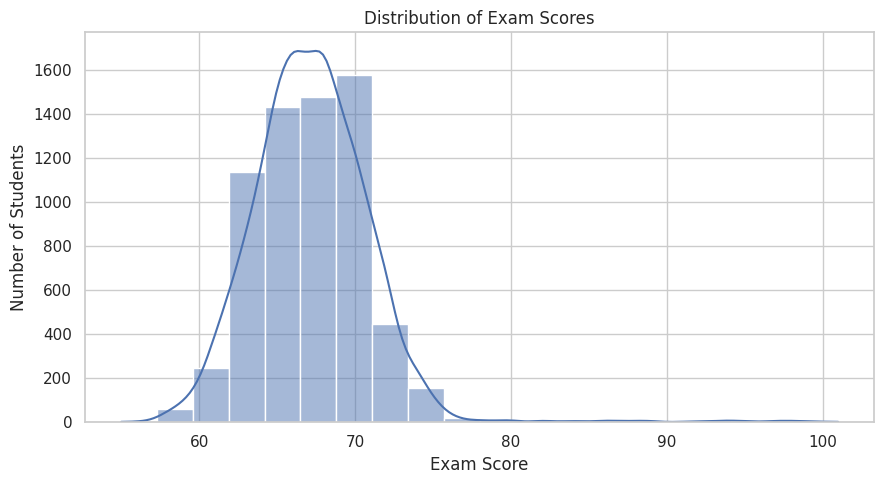

In [12]:
plt.figure(figsize=(9, 5))
sns.histplot(df['Exam_Score'], bins=20, kde=True)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

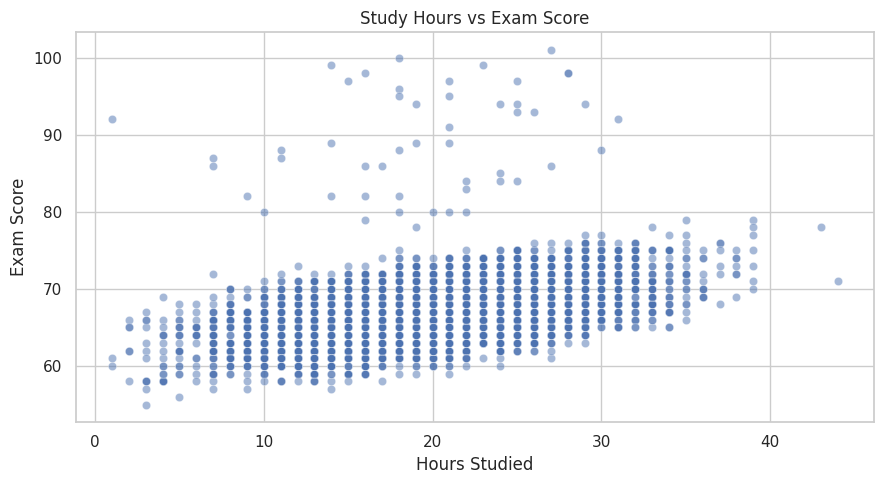

In [13]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', alpha=0.5)
plt.title('Study Hours vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

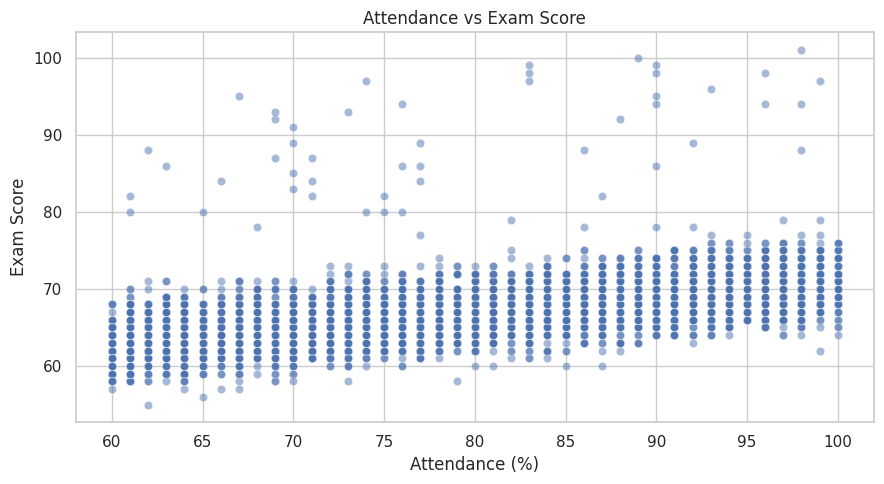

In [14]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df, x='Attendance', y='Exam_Score', alpha=0.5)
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.tight_layout()
plt.show()

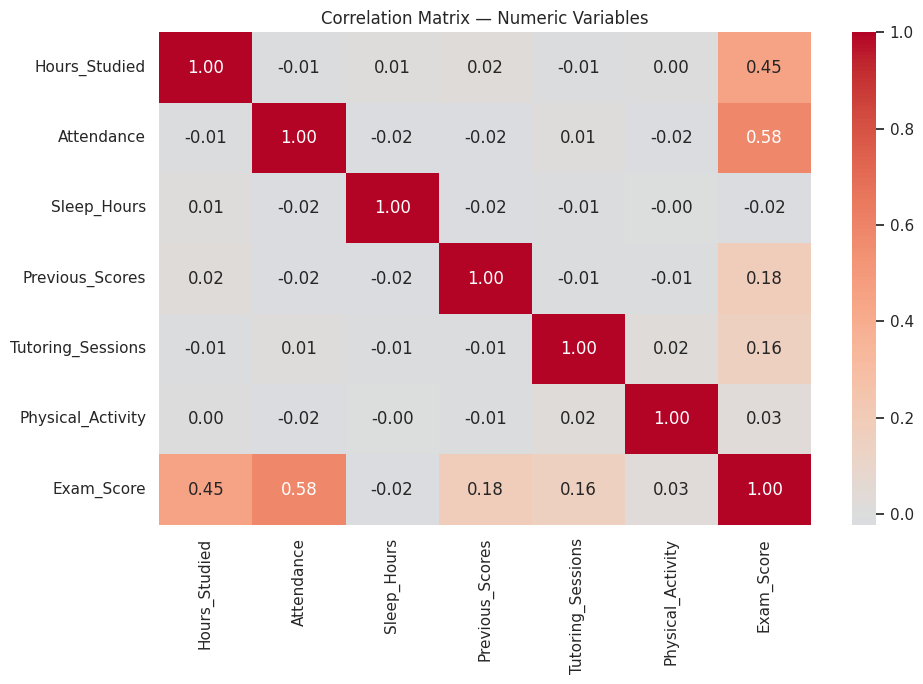

Correlation with Exam_Score:


,Correlation
Exam_Score,1.00
Attendance,0.58
Hours_Studied,0.45
Previous_Scores,0.18
Tutoring_Sessions,0.16
Physical_Activity,0.03
Sleep_Hours,-0.02


In [15]:
corr = df.select_dtypes(include=np.number).corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()

print('Correlation with Exam_Score:')
display(corr['Exam_Score'].sort_values(ascending=False).to_frame('Correlation'))

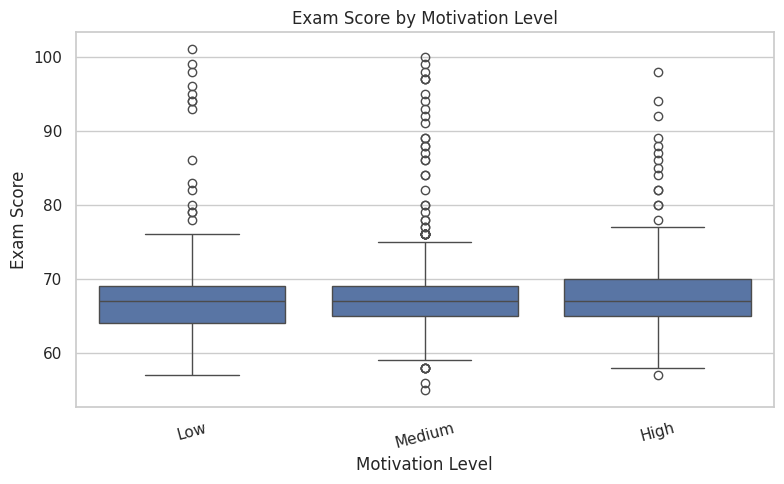

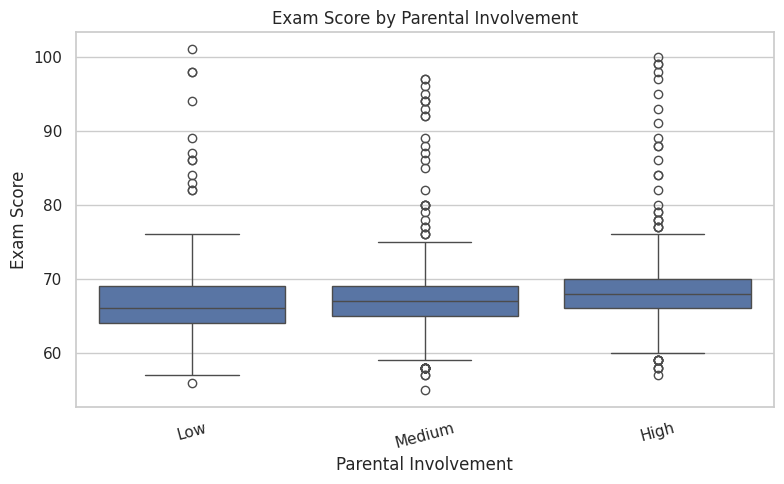

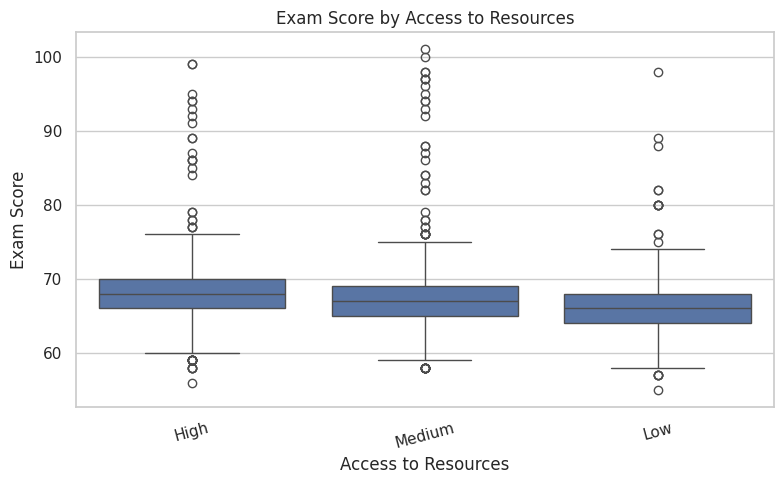

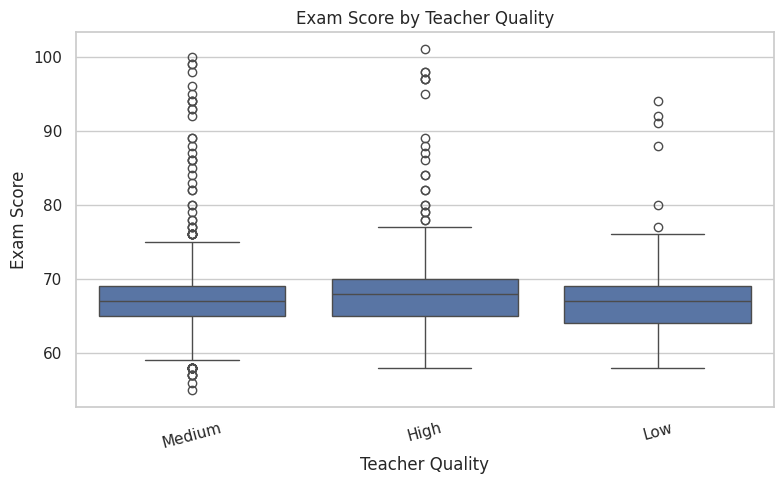

In [16]:
categorical_to_plot = ['Motivation_Level', 'Parental_Involvement', 'Access_to_Resources', 'Teacher_Quality']

for col in categorical_to_plot:
    if col in df.columns:
        plt.figure(figsize=(8, 5))
        sns.boxplot(data=df, x=col, y='Exam_Score')
        plt.title(f'Exam Score by {col.replace("_", " ")}')
        plt.xlabel(col.replace('_', ' '))
        plt.ylabel('Exam Score')
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()

In [17]:
print('Final shape:', df.shape)
print('Missing cells:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Numeric columns:', len(df.select_dtypes(include=np.number).columns))
print('Categorical columns:', len(df.select_dtypes(exclude=np.number).columns))

assert df.isna().sum().sum() == 0, 'Missing values remain.'
assert df.duplicated().sum() == 0, 'Duplicate rows remain.'
print('Quality checks passed.')

Final shape: (6607, 20)
Missing cells: 0
Duplicate rows: 0
Numeric columns: 7
Categorical columns: 13
Quality checks passed.


In [18]:
cleaned_path = 'student_performance_cleaned.csv'
df.to_csv(cleaned_path, index=False)
print(f'Saved: {cleaned_path}')

from google.colab import files
files.download(cleaned_path)

Saved: student_performance_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# GIST Data Science Internship — Task 3
## Data Analysis & Prediction

**Domain:** Data Science  
**Task:** Task 3 — Advanced: Data Analysis & Prediction

### Objective
Prepare a real-world student-performance dataset, perform feature engineering, analyze important variables, build a predictive model, evaluate its results, and present the findings in a professional analysis report.

### Dataset
Student Performance Factors — Kaggle: https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

### Important modeling decision
`Exam_Score` is the prediction target. The model predicts exam score from student-related factors. `Exam_Score` is never used as an input feature, preventing target leakage.

In [19]:
!pip -q install kagglehub

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')
sns.set_theme(style='whitegrid')
print('Libraries loaded.')

Libraries loaded.


In [20]:
import kagglehub
dataset_path = kagglehub.dataset_download('lainguyn123/student-performance-factors')
csv_files = glob.glob(os.path.join(dataset_path, '**', '*.csv'), recursive=True)
if not csv_files:
    raise FileNotFoundError('No CSV file found.')
csv_path = csv_files[0]
df = pd.read_csv(csv_path)
print('Shape:', df.shape)
display(df.head())

Using Colab cache for faster access to the 'student-performance-factors' dataset.
Shape: (6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [21]:
df = df.copy()
print('Missing values before treatment:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
df = df.drop_duplicates().reset_index(drop=True)
print('Rows after duplicate removal:', len(df))
display(df.describe(include='all').T)

Missing values before treatment: 235
Duplicate rows: 0
Rows after duplicate removal: 6607


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Hours_Studied,"6,607.000",NaN,NaN,NaN,19.975,5.991,1.000,16.000,20.000,24.000,44.000
Attendance,"6,607.000",NaN,NaN,NaN,79.977,11.547,60.000,70.000,80.000,90.000,100.000
Parental_Involvement,6607,3,Medium,3362,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Access_to_Resources,6607,3,Medium,3319,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Extracurricular_Activities,6607,2,Yes,3938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sleep_Hours,"6,607.000",NaN,NaN,NaN,7.029,1.468,4.000,6.000,7.000,8.000,10.000
Previous_Scores,"6,607.000",NaN,NaN,NaN,75.071,14.400,50.000,63.000,75.000,88.000,100.000
Motivation_Level,6607,3,Medium,3351,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Internet_Access,6607,2,Yes,6108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tutoring_Sessions,"6,607.000",NaN,NaN,NaN,1.494,1.231,0.000,1.000,1.000,2.000,8.000


In [22]:
def engineer_features(data):
    data = data.copy()
    if {'Hours_Studied','Attendance'}.issubset(data.columns):
        data['Study_Attendance_Index'] = data['Hours_Studied'] * (data['Attendance'] / 100)
    if {'Hours_Studied','Sleep_Hours'}.issubset(data.columns):
        data['Study_Sleep_Index'] = data['Hours_Studied'] * data['Sleep_Hours']
    if {'Previous_Scores','Hours_Studied'}.issubset(data.columns):
        data['Previous_Score_Study_Ratio'] = data['Previous_Scores'] / (data['Hours_Studied'] + 1)
    return data

df = engineer_features(df)
display(df.head())

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Attendance_Index,Study_Sleep_Index,Previous_Score_Study_Ratio
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67,19.320,161,3.042
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61,12.160,152,2.950
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74,23.520,168,3.640
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71,25.810,232,3.267
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70,17.480,114,3.250


In [23]:
numeric_for_corr = df.select_dtypes(include=np.number)
corr = numeric_for_corr.corr()['Exam_Score'].sort_values(ascending=False)
display(corr.to_frame('Correlation with Exam_Score'))

top_corr = corr.drop('Exam_Score').abs().sort_values(ascending=False).head(8).index
print('Top associated numeric variables:', list(top_corr))

,Correlation with Exam_Score
Exam_Score,1.000
Study_Attendance_Index,0.652
Attendance,0.581
Hours_Studied,0.445
Study_Sleep_Index,0.349
Previous_Scores,0.175
Tutoring_Sessions,0.157
Physical_Activity,0.028
Sleep_Hours,-0.017
Previous_Score_Study_Ratio,-0.243


Top associated numeric variables: ['Study_Attendance_Index', 'Attendance', 'Hours_Studied', 'Study_Sleep_Index', 'Previous_Score_Study_Ratio', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


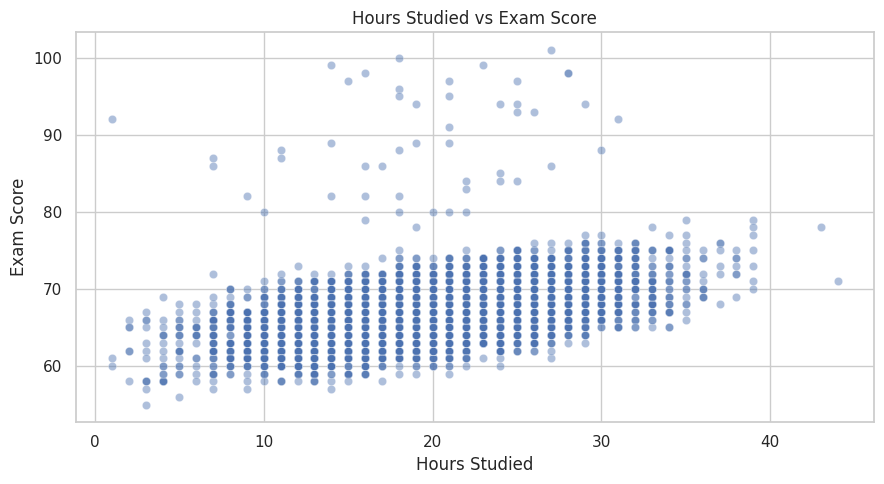

In [24]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='Hours_Studied', y='Exam_Score', alpha=0.45)
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.tight_layout(); plt.show()

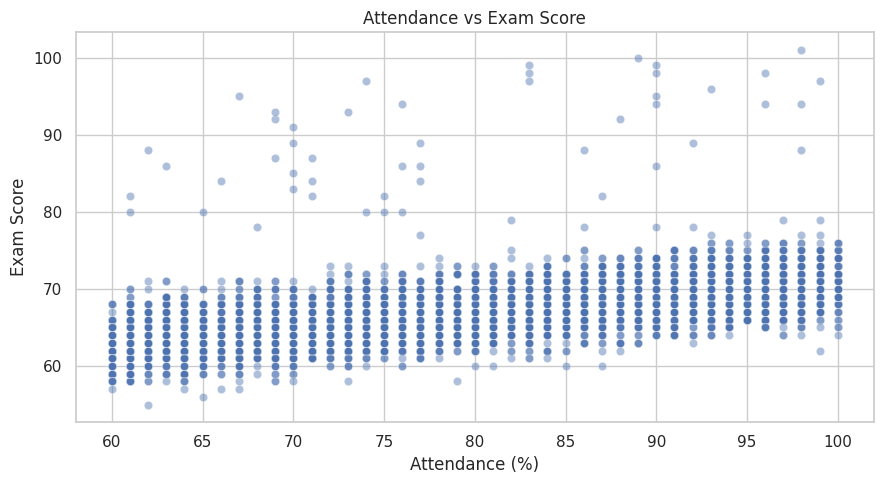

In [25]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x='Attendance', y='Exam_Score', alpha=0.45)
plt.title('Attendance vs Exam Score')
plt.xlabel('Attendance (%)')
plt.ylabel('Exam Score')
plt.tight_layout(); plt.show()

In [26]:
target='Exam_Score'
X=df.drop(columns=[target])
y=df[target]

numeric_features=X.select_dtypes(include=np.number).columns.tolist()
categorical_features=X.select_dtypes(exclude=np.number).columns.tolist()

print('Target:', target)
print('Numeric features:', len(numeric_features))
print('Categorical features:', len(categorical_features))
print('Total predictors:', X.shape[1])

Target: Exam_Score
Numeric features: 9
Categorical features: 13
Total predictors: 22


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 5285
Testing rows: 1322


In [28]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])
print('Preprocessing pipeline ready.')

Preprocessing pipeline ready.


In [29]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1))
])

rf_pipeline.fit(X_train, y_train)
rf_pred = rf_pipeline.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print(f'Random Forest MAE : {rf_mae:.3f}')
print(f'Random Forest RMSE: {rf_rmse:.3f}')
print(f'Random Forest R²  : {rf_r2:.3f}')

Random Forest MAE : 1.066
Random Forest RMSE: 2.150
Random Forest R²  : 0.673


In [30]:
gb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(random_state=42))
])
gb_pipeline.fit(X_train, y_train)
gb_pred = gb_pipeline.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_r2 = r2_score(y_test, gb_pred)

results = pd.DataFrame({
    'Model':['Random Forest','Gradient Boosting'],
    'MAE':[rf_mae,gb_mae],
    'RMSE':[rf_rmse,gb_rmse],
    'R2':[rf_r2,gb_r2]
}).sort_values('RMSE')
display(results)

,Model,MAE,RMSE,R2
1,Gradient Boosting,0.763,1.927,0.737
0,Random Forest,1.066,2.150,0.673


In [31]:
best_name = results.iloc[0]['Model']
if best_name == 'Random Forest':
    base_pipeline = rf_pipeline
    param_dist = {
        'model__n_estimators':[200,300,500],
        'model__max_depth':[None,10,20,30],
        'model__min_samples_split':[2,5,10],
        'model__min_samples_leaf':[1,2,4],
        'model__max_features':['sqrt','log2',1.0]
    }
else:
    base_pipeline = gb_pipeline
    param_dist = {
        'model__n_estimators':[100,200,300],
        'model__learning_rate':[0.03,0.05,0.1],
        'model__max_depth':[2,3,4],
        'model__min_samples_split':[2,5,10],
        'model__min_samples_leaf':[1,2,4]
    }

search = RandomizedSearchCV(
    base_pipeline,
    param_distributions=param_dist,
    n_iter=12,
    scoring='neg_root_mean_squared_error',
    cv=3,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train,y_train)
tuned_model=search.best_estimator_
tuned_pred=tuned_model.predict(X_test)

tuned_mae=mean_absolute_error(y_test,tuned_pred)
tuned_rmse=np.sqrt(mean_squared_error(y_test,tuned_pred))
tuned_r2=r2_score(y_test,tuned_pred)

print('Best parameters:')
print(search.best_params_)
print(f'Tuned MAE : {tuned_mae:.3f}')
print(f'Tuned RMSE: {tuned_rmse:.3f}')
print(f'Tuned R²  : {tuned_r2:.3f}')

Best parameters:
{'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': 2, 'model__learning_rate': 0.1}
Tuned MAE : 0.674
Tuned RMSE: 1.897
Tuned R²  : 0.745


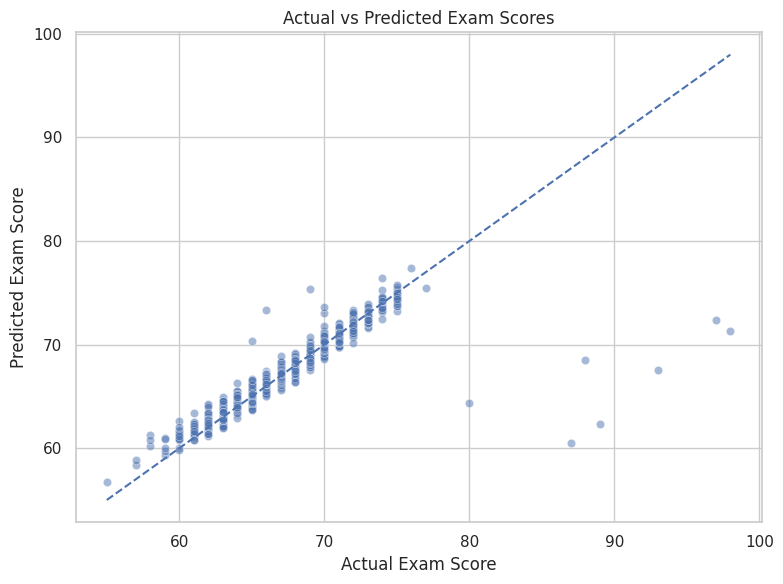

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test,y=tuned_pred,alpha=0.5)
lims=[min(y_test.min(),tuned_pred.min()),max(y_test.max(),tuned_pred.max())]
plt.plot(lims,lims,linestyle='--')
plt.title('Actual vs Predicted Exam Scores')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.tight_layout(); plt.show()

,Importance
num__Study_Attendance_Index,0.479
num__Attendance,0.254
num__Previous_Scores,0.047
num__Tutoring_Sessions,0.035
cat__Parental_Involvement_High,0.026
cat__Access_to_Resources_High,0.024
cat__Access_to_Resources_Low,0.020
cat__Parental_Involvement_Low,0.014
num__Previous_Score_Study_Ratio,0.009
cat__Family_Income_Low,0.008


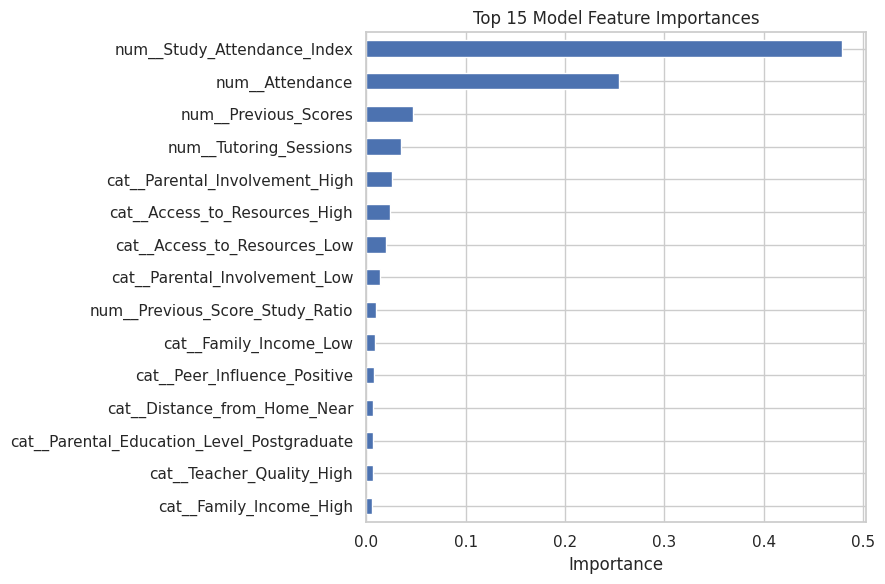

In [33]:
model=tuned_model.named_steps['model']
prep=tuned_model.named_steps['preprocessor']
feature_names=prep.get_feature_names_out()
importance=pd.Series(model.feature_importances_,index=feature_names).sort_values(ascending=False).head(15)
display(importance.to_frame('Importance'))

plt.figure(figsize=(9,6))
importance.sort_values().plot(kind='barh')
plt.title('Top 15 Model Feature Importances')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

,Actual,Predicted,Absolute_Error
count,"1,322.000","1,322.000","1,322.000"
mean,67.318,67.376,0.674
std,3.761,3.147,1.774
min,55.000,56.764,0.001
25%,65.000,65.171,0.213
50%,67.000,67.280,0.442
75%,70.000,69.602,0.778
max,98.000,77.437,26.722


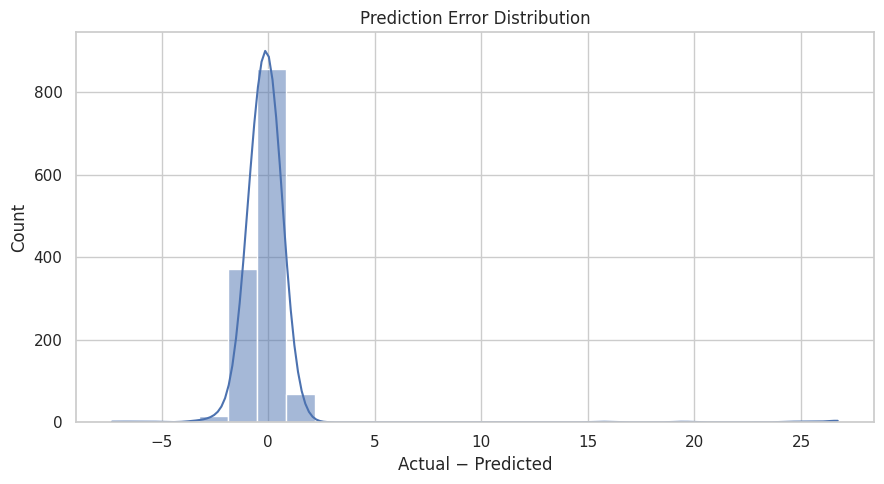

In [34]:
error_df=pd.DataFrame({'Actual':y_test.values,'Predicted':tuned_pred})
error_df['Absolute_Error']=(error_df['Actual']-error_df['Predicted']).abs()
display(error_df.describe())

plt.figure(figsize=(9,5))
sns.histplot(error_df['Actual']-error_df['Predicted'],bins=25,kde=True)
plt.title('Prediction Error Distribution')
plt.xlabel('Actual − Predicted')
plt.ylabel('Count')
plt.tight_layout(); plt.show()

### Report template
- **Data preparation:** duplicates were removed and missing values were handled inside the modeling pipeline.
- **Feature engineering:** derived study/attendance and study/sleep indicators were created from existing predictor variables.
- **Model comparison:** Random Forest and Gradient Boosting were evaluated using MAE, RMSE, and R².
- **Model selection:** the model with the lower test RMSE was selected before tuning.
- **Optimization:** randomized cross-validation was used to search a practical hyperparameter space.
- **Evaluation:** actual-vs-predicted and error-distribution plots were used to inspect prediction quality.
- **Important variables:** the feature-importance chart identifies the strongest predictors according to the final tree-based model.

### Conclusion
The project demonstrates an end-to-end Data Science workflow: data preparation → feature engineering → analysis → model comparison → hyperparameter tuning → evaluation → interpretation.

In [35]:
predictions=error_df.copy()
predictions.to_csv('Task3_predictions.csv',index=False)
results.to_csv('model_comparison.csv',index=False)
importance.to_csv('feature_importance.csv',header=['Importance'])
print('Saved: Task3_predictions.csv, model_comparison.csv, feature_importance.csv')

from google.colab import files
for f in ['Task3_predictions.csv','model_comparison.csv','feature_importance.csv']:
    files.download(f)

Saved: Task3_predictions.csv, model_comparison.csv, feature_importance.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#GIST Data Science Internship — Task 4
##Interactive Data Dashboard

**Domain:** Data Science

**Task:** Task 4 — Advanced+: Interactive Data Dashboard

###Objective

Create an interactive data dashboard by connecting a dataset, implementing filters and key performance indicators (KPIs), visualizing important trends, and generating actionable insights.

###Dataset

Retail Sales Dataset — contains order-level data including OrderID, Date, Region, Category, Segment, Revenue, and Profit for business analysis.

###Important Dashboard Design Decision

KPIs such as Total Revenue, Total Profit, Total Orders, Average Order Value, and Profit Margin are calculated from the dataset. Filters like Region, Category, and Segment are applied dynamically to update visualizations and insights in real time.

In [47]:
!pip install plotly pandas

import pandas as pd
import numpy as np
import plotly.express as px

In [48]:
np.random.seed(42)

n = 500

df = pd.DataFrame({
    "OrderID": np.arange(1, n+1),
    "Date": pd.date_range(start="2023-01-01", periods=n, freq="D"),
    "Region": np.random.choice(["North", "South", "East", "West"], n),
    "Category": np.random.choice(["Electronics", "Clothing", "Furniture"], n),
    "Segment": np.random.choice(["Consumer", "Corporate", "Home Office"], n),
    "Revenue": np.random.randint(100, 1000, n),
    "Profit": np.random.randint(10, 300, n)
})

df['Month'] = df['Date'].dt.to_period('M').astype(str)

In [49]:
total_revenue = df['Revenue'].sum()
total_profit = df['Profit'].sum()
total_orders = df['OrderID'].nunique()
avg_order_value = total_revenue / total_orders
profit_margin = (total_profit / total_revenue) * 100

print("KPIs")
print("Total Revenue:", total_revenue)
print("Total Profit:", total_profit)
print("Total Orders:", total_orders)
print("Avg Order Value:", round(avg_order_value, 2))
print("Profit Margin %:", round(profit_margin, 2))

KPIs
Total Revenue: 268414
Total Profit: 75884
Total Orders: 500
Avg Order Value: 536.83
Profit Margin %: 28.27


In [50]:
region_filter = "All"
category_filter = "All"

filtered_df = df.copy()

if region_filter != "All":
    filtered_df = filtered_df[filtered_df['Region'] == region_filter]

if category_filter != "All":
    filtered_df = filtered_df[filtered_df['Category'] == category_filter]

In [51]:
monthly_sales = filtered_df.groupby('Month')['Revenue'].sum().reset_index()

fig1 = px.line(
    monthly_sales,
    x='Month',
    y='Revenue',
    title='Monthly Revenue Trend',
    markers=True
)
fig1.show()

In [52]:
cat_sales = filtered_df.groupby('Category')['Revenue'].sum().reset_index()

fig2 = px.bar(
    cat_sales,
    x='Category',
    y='Revenue',
    title='Revenue by Category',
    color='Category'
)
fig2.show()

In [53]:
region_sales = filtered_df.groupby('Region')['Revenue'].sum().reset_index()

fig3 = px.pie(
    region_sales,
    names='Region',
    values='Revenue',
    title='Revenue by Region'
)
fig3.show()

In [54]:
fig4 = px.scatter(
    filtered_df,
    x='Revenue',
    y='Profit',
    title='Profit vs Revenue',
    color='Category'
)
fig4.show()

In [56]:
top_category = cat_sales.sort_values(by='Revenue', ascending=False).iloc[0]['Category']
top_region = region_sales.sort_values(by='Revenue', ascending=False).iloc[0]['Region']

print("\nActionable Insights")

print(f"Top Category: {top_category}")
print(f"Best Region: {top_region}")

if profit_margin < 15:
    print("Low profit margin → consider reducing costs or increasing prices")

if monthly_sales['Revenue'].iloc[-1] < monthly_sales['Revenue'].mean():
    print("Recent sales below average → increase marketing or promotions")

print("Focus on high-performing category and expand in best region")


Actionable Insights
Top Category: Electronics
Best Region: West
Recent sales below average → increase marketing or promotions
Focus on high-performing category and expand in best region
